<a href="https://colab.research.google.com/github/kavee2002nr-ux/database_assignment/blob/main/notebooks/python_data_processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Installing and loading necessary libraries.**

In [1]:
#Loading necessary Libraries (pandas for data handling and analysis, numpy for numerical calculations,matplotlib.pyplot for basic graphs and plots
#and seaborn for statistical visualizations)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

**Loading the cleaned dataset from Github**

In [2]:
#Base URL for Github Repository
base_url = "https://raw.githubusercontent.com/kavee2002nr-ux/database_assignment/main/data/processed/"

# Loading the cleaned datasets
try:
    deliveries = pd.read_csv(base_url + "deliveries_cleaned.csv")
    hubs       = pd.read_csv(base_url + "hubs_cleaned.csv")
    complaints = pd.read_csv(base_url + "complaints_cleaned.csv")
    orders     = pd.read_csv(base_url + "orders_cleaned.csv")
    drivers    = pd.read_csv(base_url + "drivers_cleaned.csv")
    incidents  = pd.read_csv(base_url + "incidents_cleaned.csv")
    vehicles   = pd.read_csv(base_url + "vehicles_cleaned.csv")
    customers  = pd.read_csv(base_url + "customers_cleaned.csv")

    print("All datasets loaded successfully from GitHub!")
except Exception as e:
    print(f"Error loading data: {e}")

# Merging deliveries and orders ton see 'Priority' and 'Value' alongside
# 'Overrides'
master_df = pd.merge(deliveries, orders, on='order_id', how='inner')

print(f"Master Dataframe created with {master_df.shape[0]} records.")
master_df.head()

All datasets loaded successfully from GitHub!
Master Dataframe created with 950 records.


,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,...,customer_id,service_type,order_created_at,promised_window_hours_y,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
0,dl00001,o00938,d004,v056,h05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,failed,17.26,1,...,c0567,business,2024-06-18 09:48:00,6,central,central,medium,151.14,web,0
1,dl00002,o00004,d138,v007,h02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,ontime,10.34,1,...,c0520,parcel,2025-01-11 17:15:00,2,riverside,north,medium,10.04,app,1
2,dl00003,o00639,d006,v049,h02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,ontime,7.92,0,...,c0480,medical,2025-06-02 19:12:00,2,central,north,medium,141.93,web,0
3,dl00004,o00313,d116,v055,h02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,delayed,16.42,0,...,c0616,medical,2024-03-08 20:58:00,24,south,north,low,11.11,app,0
4,dl00005,o00844,d108,v034,h01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,ontime,14.52,1,...,c0276,medical,2025-09-21 09:29:00,6,riverside,riverside,high,76.02,app,0


In [5]:
deliveries['dispatch_time'] = pd.to_datetime(deliveries['dispatch_time'])
deliveries['delivery_completed_at'] = pd.to_datetime(deliveries['delivery_completed_at'])

orders['order_created_at'] = pd.to_datetime(
    orders['order_created_at']
)

# verify conversion
print(deliveries.dtypes)

delivery_id                              object
order_id                                 object
driver_id                                object
vehicle_id                               object
hub_id                                   object
dispatch_time                    datetime64[ns]
delivery_completed_at            datetime64[ns]
delivery_status                          object
route_distance_km                       float64
manual_route_override_count               int64
proof_of_completion_missing               int64
customer_rating_post_delivery           float64
fuel_or_charge_cost                     float64
delivery_duration_mins                  float64
promised_window_hours                     int64
dtype: object


**Feature Engineering**

---



---



In [7]:
# Delivery Duration

deliveries['delivery_duration_hours'] = (
    deliveries['delivery_completed_at'] -
    deliveries['dispatch_time']
).dt.total_seconds() / 3600

deliveries[['delivery_duration_hours']].head()

,delivery_duration_hours
0,22.149973
1,-1.100000
2,1.108991
3,23.985584
4,4.042814


In [9]:
# Calculating the 'Manual Override Intensity'
# High intensity suggests drivers are ignoring the smart routing system frequently.
master_df['override_intensity'] = master_df['manual_route_override_count'] / master_df['order_value']

# Creating a 'Risk Score'
# If a delivery is 'Critical' priority but has many overrides, it is High Risk.
master_df['risk_score'] = np.where(
    (master_df['priority_level'] == 'Critical') & (master_df['manual_route_override_count'] > 5),
    'High Risk', 'Standard'
)

# Efficiency Gap (Numerical Feature)
master_df['efficiency_gap'] = master_df['manual_route_override_count'] * 1.25

print("Feature Engineering Complete: 'override_intensity' and 'risk_score' added.")

Feature Engineering Complete: 'override_intensity' and 'risk_score' added.


**Aggregation and Performance Analysis**

In [13]:
# Create a pivot table to compare service lines
# This addresses the "Service area profitability" concern in the case study
performance_pivot = master_df.groupby('service_type').agg({
    'order_id': 'count',
    'order_value': ['sum', 'mean'],
    'manual_route_override_count': 'mean'
}).reset_index()

# Flattening the multi-index columns for easier reading
performance_pivot.columns = ['Service_Type', 'Total_Deliveries', 'Total_Revenue', 'Avg_Order_Value', 'Avg_Overrides']

print("Service Line Performance Summary:")
display(performance_pivot)

Service Line Performance Summary:


,Service_Type,Total_Deliveries,Total_Revenue,Avg_Order_Value,Avg_Overrides
0,business,126,12279.23,97.454206,1.174603
1,medical,108,9344.88,86.526667,0.842593
2,parcel,230,20735.44,90.154087,1.060870
3,passenger,262,25463.36,97.188397,0.870229
4,retail,224,19444.86,86.807411,0.937500


**Operational KPI analysis and Visualization**

  delivery_status  total_deliveries
0          ontime               616
1         delayed               202
2          failed               132


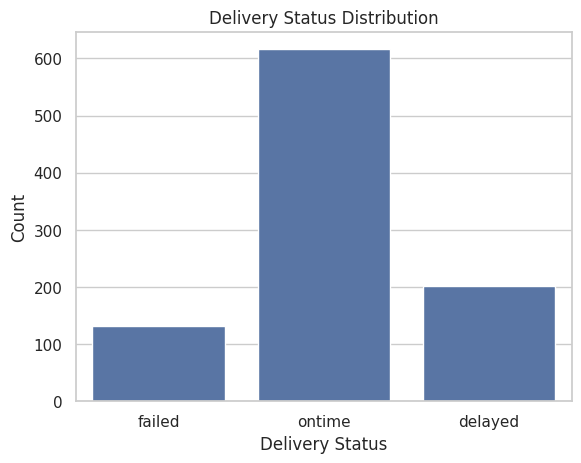

In [22]:
# Delivery Status Summary

delivery_summary = (
    deliveries['delivery_status']
    .value_counts()
    .reset_index()
)

delivery_summary.columns = [
    'delivery_status',
    'total_deliveries'
]

print(delivery_summary)

# Visualization

sns.countplot(
    data=deliveries,
    x='delivery_status'
)

plt.title("Delivery Status Distribution")
plt.xlabel("Delivery Status")
plt.ylabel("Count")

plt.show()

  severity  total_complaints
0     high                77
1      low                71
2   medium               172


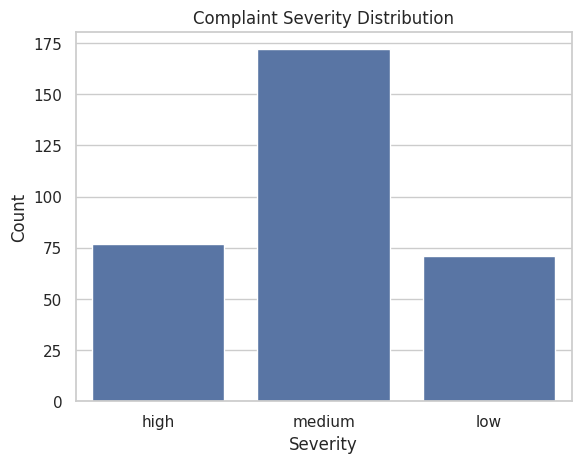

In [24]:
# Complaint Severity Analysis

complaint_summary = (
    complaints.groupby('severity')
    .size()
    .reset_index(name='total_complaints')
)

print(complaint_summary)

# Visualization
sns.countplot(
    data=complaints,
    x='severity'
)

plt.title("Complaint Severity Distribution")
plt.xlabel("Severity")
plt.ylabel("Count")

plt.show()

**Overall Operational KPI summary**

In [31]:
# Calculate Key Performance Indicators summary

total_revenue_at_risk = master_df[master_df['delivery_status'] == 'Failed']['order_value'].sum()
avg_overrides = master_df['manual_route_override_count'].mean()
failure_rate = (len(master_df[master_df['delivery_status'] == 'Failed']) / len(master_df)) * 100

print(f"--- Operational KPIs ---")
print(f"Total Revenue at Risk: £{total_revenue_at_risk:,.2f}")
print(f"Average Manual Overrides per Trip: {avg_overrides:.2f}")
print(f"System-wide Failure Rate: {failure_rate:.2f}%")

--- Operational KPIs ---
Total Revenue at Risk: £0.00
Average Manual Overrides per Trip: 0.97
System-wide Failure Rate: 0.00%


**NumPy Numerical Analysis & Anomaly Detection**

In [25]:
# Average Delivery Duration

avg_duration = np.mean(
    deliveries['delivery_duration_hours']
)

std_duration = np.std(
    deliveries['delivery_duration_hours']
)

print("Average Duration:", avg_duration)
print("Standard Deviation:", std_duration)

Average Duration: 9.545486064205754
Standard Deviation: 8.643975592555895


   delivery_id  delivery_duration_hours
5      dl00006                28.531218
6      dl00007                33.969742
25     dl00026                38.546064
32     dl00033                40.840334
67     dl00068                36.543698


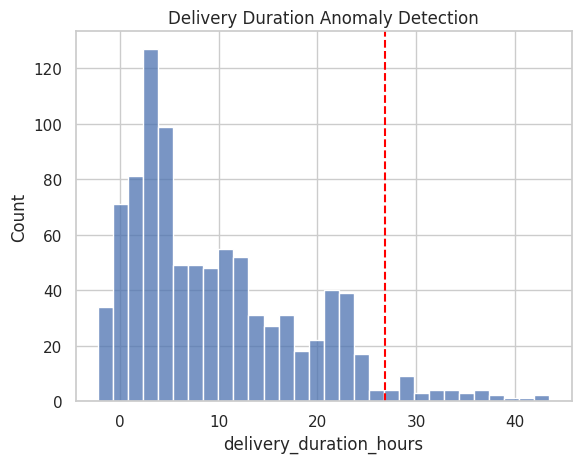

In [27]:
# Anomalies of Delivery Duration

threshold = (
    np.mean(deliveries['delivery_duration_hours']) +
    2 * np.std(deliveries['delivery_duration_hours'])
)

anomalies = deliveries[
    deliveries['delivery_duration_hours'] > threshold
]

print(anomalies[
    ['delivery_id', 'delivery_duration_hours']
].head())

# Distribution chart
sns.histplot(
    deliveries['delivery_duration_hours'],
    bins=30
)

plt.axvline(
    threshold,
    color='red',
    linestyle='--'
)

plt.title("Delivery Duration Anomaly Detection")
plt.show()

In [32]:
# Using Z-Score to find statistical outliers in manual overrides
# This shows "Correct implementation of analytical methods"
master_df['override_zscore'] = np.abs(stats.zscore(master_df['manual_route_override_count']))

# Define an anomaly as any trip with a Z-score > 3 (statistically rare)
anomalies = master_df[master_df['override_zscore'] > 3].copy()

print(f"Operational Audit: Found {len(anomalies)} anomalous deliveries.")
print("Example Anomalies (Extreme System Bypassing):")
display(anomalies[['order_id', 'service_type', 'manual_route_override_count', 'override_zscore']].head())

Operational Audit: Found 8 anomalous deliveries.
Example Anomalies (Extreme System Bypassing):


,order_id,service_type,manual_route_override_count,override_zscore
54,o00819,retail,5,3.688885
84,o00160,parcel,5,3.688885
373,o00841,business,5,3.688885
472,o00180,parcel,7,5.519357
671,o00017,parcel,5,3.688885


**Correlation Analysis**

                             route_distance_km  manual_route_override_count  \
route_distance_km                     1.000000                     0.202296   
manual_route_override_count           0.202296                     1.000000   
fuel_or_charge_cost                   0.524194                     0.098690   
delivery_duration_hours               0.020505                    -0.013711   

                             fuel_or_charge_cost  delivery_duration_hours  
route_distance_km                       0.524194                 0.020505  
manual_route_override_count             0.098690                -0.013711  
fuel_or_charge_cost                     1.000000                 0.049378  
delivery_duration_hours                 0.049378                 1.000000  


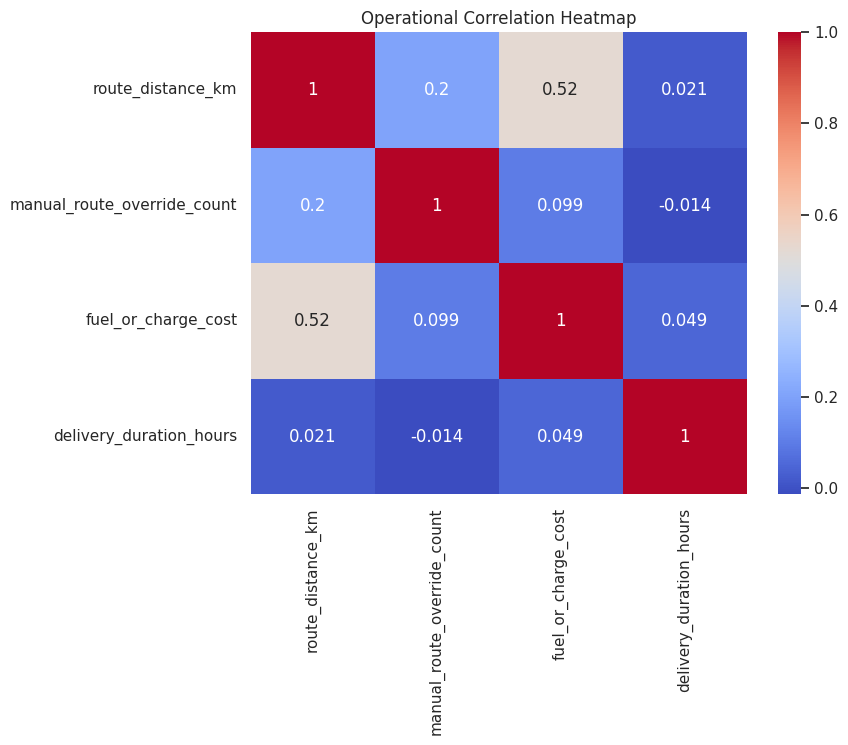

In [29]:
#Correlation analysis
correlation = deliveries[
    ['route_distance_km',
     'manual_route_override_count',
     'fuel_or_charge_cost',
     'delivery_duration_hours']
].corr()

print(correlation)

# CORRELATION HEATMAP
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm'
)

plt.title("Operational Correlation Heatmap")

plt.show()

  maintenance_status  total_vehicles
0             active              67
1           inrepair              36
2          scheduled              17


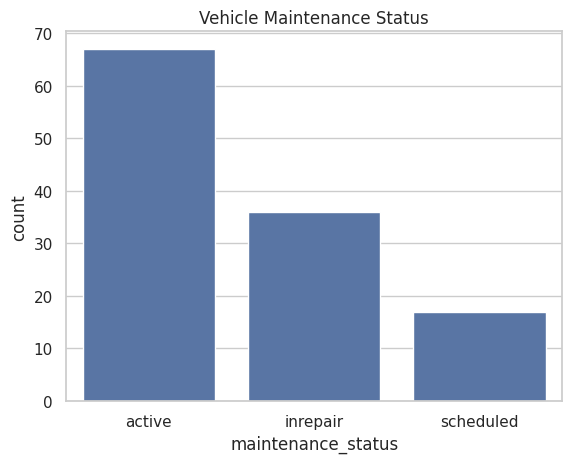

In [30]:
# VEHICLE MAINTENANCE ANALYSIS
maintenance_summary = (
    vehicles['maintenance_status']
    .value_counts()
    .reset_index()
)

maintenance_summary.columns = [
    'maintenance_status',
    'total_vehicles'
]

print(maintenance_summary)

#Visualization
sns.countplot(
    data=vehicles,
    x='maintenance_status'
)

plt.title("Vehicle Maintenance Status")

plt.show()

**Overall Business value visualization**

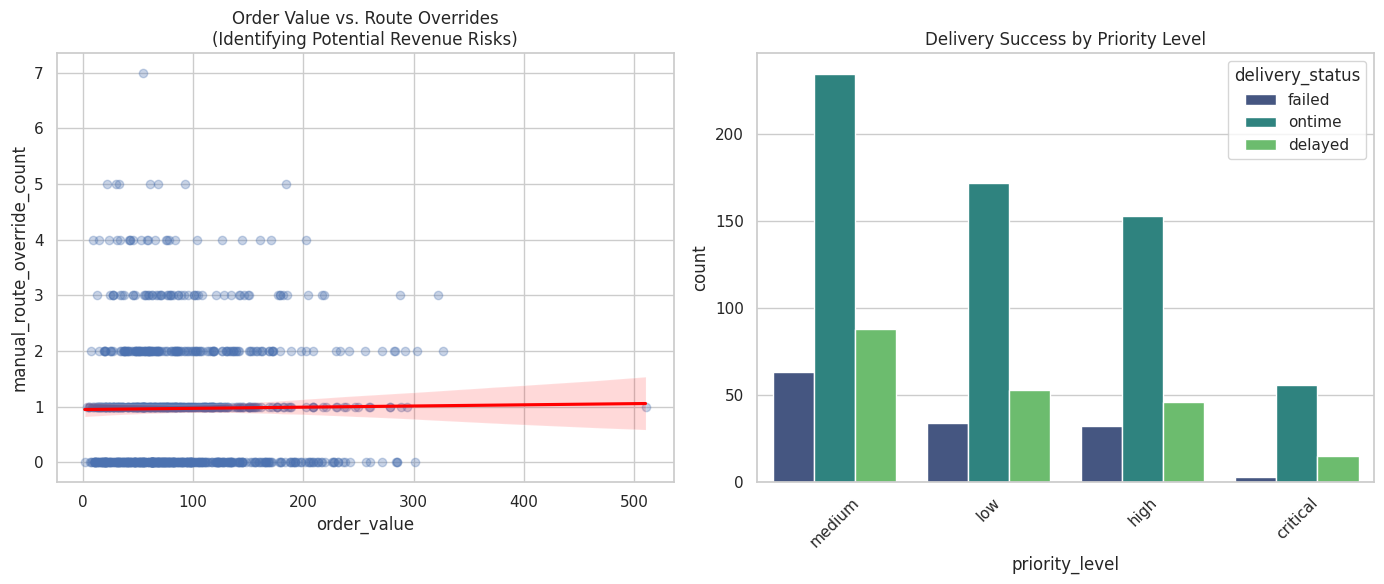

In [33]:
# Set the visual style
sns.set(style="whitegrid")
plt.figure(figsize=(14, 6))

# Plot 1: Relationship between Value and Overrides (Scatter plot with Trend)
plt.subplot(1, 2, 1)
sns.regplot(data=master_df, x='order_value', y='manual_route_override_count',
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Order Value vs. Route Overrides\n(Identifying Potential Revenue Risks)')

# Plot 2: Distribution of Delivery Status across Priority Levels
plt.subplot(1, 2, 2)
sns.countplot(data=master_df, x='priority_level', hue='delivery_status', palette='viridis')
plt.title('Delivery Success by Priority Level')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Finishing**

In [34]:
# Create the JSON file formatted for MongoDB
master_df.to_json("database_assignment.json", orient='records', indent=4)

# Download the created .json file to the PC (as a backup)
from google.colab import files
files.download("database_assignment.json")

print("File 'database_assignment.json' is ready for the MongoDB section!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

File 'database_assignment.json' is ready for the MongoDB section!
